## Tutorial para visualizar y analizar señales electrofisiológicas con una función de zoom.

En este caso trabajaremos con el procesamiento de señales de EMG (electromiograma). Una señal de EMG es una medida de la actividad eléctrica producida por músculos al contraerse. De esta manera se puede capturar la actividad neuromuscular del cuerpo, con el uso potencial de diagnosticar la salud del músculo y desórdenes neurológicos.

Para realizar electromiogramas se colocan tres electrodos de la siguiente manera: 2 en el músculo de interés con el objetivo de captar la actividad eléctrica y otro alejado de la zona de interés, que toma el papel de tierra. Existen dos tipos de electrodos que alcanzan objetivos distintos: los electrodos de superficie permiten realizar registros rápidos de áreas grandes, pero suelen capturar más ruido, mientras que los electrodos de aguja permiten un enfoque más focalizado y con menos ruido, con la desventaja de ser más invasivos.

En esta práctica utilizamos el hardware Spikerbox de Backyard Brains con el software provisto por el fabricante. Colocamos los electrodos en el área de interés y contraemos el músculo múltiples veces para observar la actividad en el registro. Es importante revisar que la caja tenga batería y poner atención a no desconectar los electrodos de la piel cuando el spikerbox esté encendido, esto produce un sonido fuerte que puede dañar el amplificador.

Posteriormente el registro se guarda como archivo wav, el cual podemos visualizar con el código siguiente.

In [1]:
# comando para poder ver gráficos en el
%matplotlib widget


# import plotting module
import matplotlib.pyplot as plt

In [2]:
import math
import numpy as np
import scipy as sc
import wave
import ipywidgets as widgets
from scipy import signal
from scipy.io import wavfile
from scipy.signal import butter, lfilter, filtfilt
from ipywidgets import interact, interactive, fixed, interact_manual
from matplotlib.widgets import SpanSelector, Slider, Button
from IPython.display import display
from statsmodels.distributions.empirical_distribution import ECDF

In [3]:
def EMG(file):
    # abrir el archivo wav
    record = wave.open(file)
    # extraer el número de canales, la tasa de muestreo y los datos
    numChannels = record.getnchannels() 
    N = record.getnframes() 
    sampleRate = record.getframerate()
    
    dstr = record.readframes(N * numChannels)
    waveData = np.frombuffer(dstr, np.int16)
    # imprimir el número de canales y la tasa de muestreo
    print('The recording has %d channel(s).' % (numChannels))
    print('The sampling rate of the recording is %d Hz.' % (sampleRate))
    # calcular el tiempo transcurrido
    timeEMG=np.linspace(0, len(waveData)/sampleRate, num=len(waveData))
    # calcular las frecuencias presentes
    freq = 1/np.mean(np.diff(timeEMG))

      # guardar la información relevante en un arreglo
    xx={'sampleRate':sampleRate,\
        'waveData':waveData,\
        'timeEMG':timeEMG,\
        'freq':freq}
    
    # Graficar la señal e implementar un widget que permita hacer zoom a las partes de mayor interés
    fig, (ax1,ax2) = plt.subplots(2,figsize=(12,6))
    ax1.plot(timeEMG,waveData, 'b')
    ax1.set_ylabel(r'voltage ($\mu$V)')
    fig.suptitle('Gráfica interactiva de la onda EMG')

    
    line2, = ax2.plot(timeEMG, waveData, 'b')
    ax2.set_xlabel(r'time (s)')
    ax2.set_ylabel(r'voltage ($\mu$V)')

    # La función onselect junto con el SpanSelector se encargan de actualizar la gráfica con los límites horizontales seleccionados sobre la gráfica
    # El zoom ajusta los límites de graficación sobre X, de manera que permite enfocarse en un pico o algún otro punto de interés
    def onselect(xmin, xmax):
        indmin, indmax = np.searchsorted(timeEMG, (xmin, xmax))
        indmax = min(len(timeEMG) - 1, indmax)

        thisx = timeEMG[indmin:indmax]
        thisy = waveData[indmin:indmax]
        line2.set_data(thisx, thisy)
        ax2.set_xlim(thisx[0], thisx[-1])
        ax2.set_ylim(thisy.min(), thisy.max())
        fig.canvas.draw()
        print(f'The selected range is ({xmin}, {xmax})')

    span = SpanSelector(ax1, onselect, 'horizontal', useblit=True,
                        props=dict(alpha=0.5, facecolor='red'))


    
    plt.show()
    return xx

The recording has 1 channel(s).
The sampling rate of the recording is 44100 Hz.


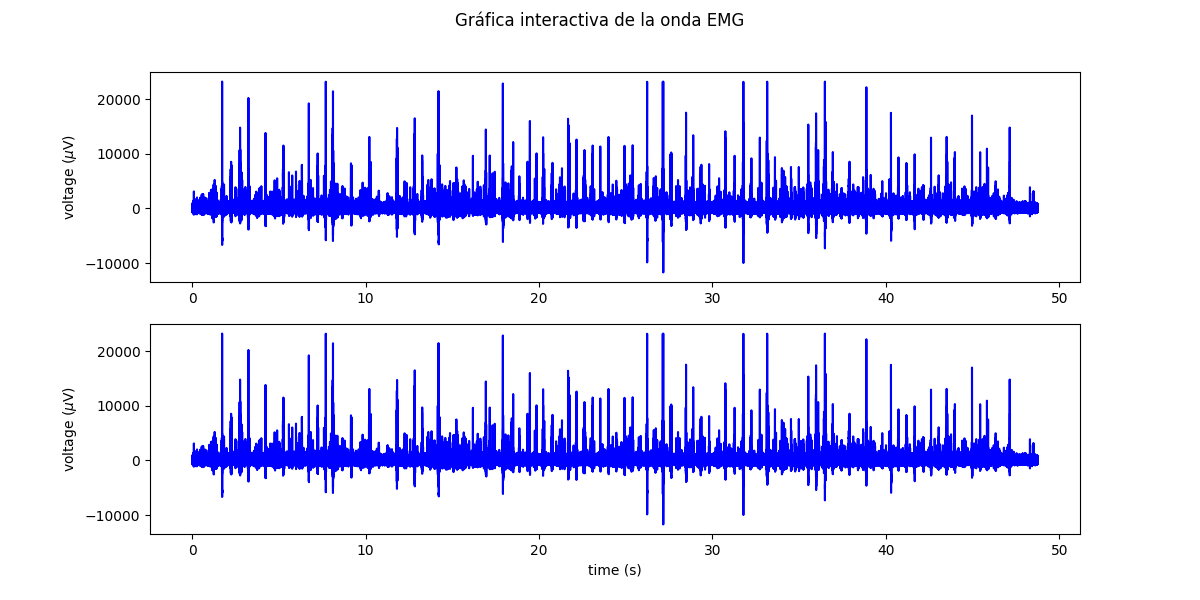

In [4]:
longbiceps = '/Users/pipeavina/Downloads/RegistroFlexoresLateralMedialLuis.wav' # Coloca el path del archivo wav que desees visualizar
xx = EMG(longbiceps)

### Filtrado
Aquí implementamos un primer filtro bandpass de la señal para tener un enfoque en los voltajes que se presentan en electromiogramas. Además, contruimos un histograma que nos permite confirmar la presencia de frecuencias mayoritariamente en el rango definido.

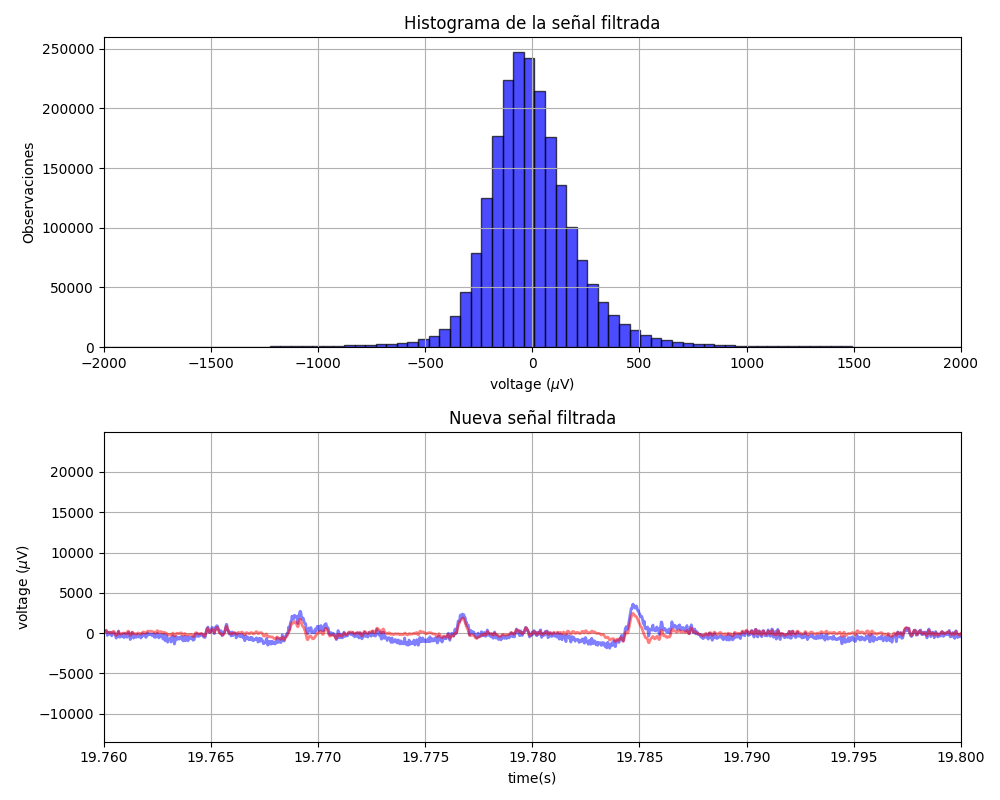

In [ ]:
fs, data = wavfile.read(longbiceps)

#bandpass
def butter_bandpass(lowcut, highcut, fs, order=2):
    nyquist = 0.5 * fs
    low = lowcut / nyquist
    high = highcut / nyquist
    b, a = butter(order, [low, high], btype='bandpass')
    return b, a

def bandpass_filter(data, lowcut, highcut, fs, order=2):
    b, a = butter_bandpass(lowcut, highcut, fs, order=order)
    dataf = filtfilt(b, a, xx['waveData'])
    return dataf

#parámetros de filtrado
lowcut = 300.0
highcut = 6000.0

#filtro
filtered_data = bandpass_filter(data, lowcut, highcut, fs)
wavfile.write('señal_filtrada.wav', fs, filtered_data.astype(np.int16))

# Creación de la figura y los ejes
fig, ax = plt.subplots(2, 1, figsize=(10, 8))

# Histograma de los datos filtrados
# Importante ajustar los límites de graficación y de bins para tener una granularidad satisfactoria.
# Esto porque el rango en que se presentan frecuencias es muy amplio, aún si las ocurrencias en frecuencias extremas son ínfimas.
ax[0].hist(filtered_data, bins=500, alpha=0.7, color='blue', edgecolor='black')
ax[0].set_title('Histograma de la señal filtrada')
ax[0].set_xlabel(r'voltage ($\mu$V)')
ax[0].set_ylabel('Observaciones')
ax[0].grid(True)
ax[0].set_xlim(-2000,2000)

# Gráfica de la nueva señal contra la señal filtrada
ax[1].plot(xx['timeEMG'],xx['waveData'],color='b',linewidth=2.0,alpha=0.5)
ax[1].plot(xx['timeEMG'],filtered_data, color='r',linewidth=2.0,alpha=0.5)

ax[1].set_title('Nueva señal filtrada')
ax[1].set_xlabel(r'time(s)')
ax[1].set_ylabel(r'voltage ($\mu$V)')
ax[1].grid(True)
ax[1].set_xlim(19.76,19.80);

# Mostrar la figura con ambas gráficas
plt.tight_layout()



### Derivada de la señal
Usamos np.gradient para obtener una derivada de la señal, np.gradient usa la derivada por la derecha e izquierda para los puntos inicial y final respectivamente, mientras que usa la derivada de punto medio para el resto de los puntos. La primera implementación extrae la derivada más alta de toda la señal y no necesariamente de un rango en específico o de máximos locales, por lo que permite únicamente enfocarnos en el pico con la mayor derivada. Este se muestra como un punto rojo en la gráfica global. Posteriormente podemos ajustar los límites horizontales de graficación para enfocarnos en el pico resaltado.
La gráfica muestra la derivada en color verde.

1401746


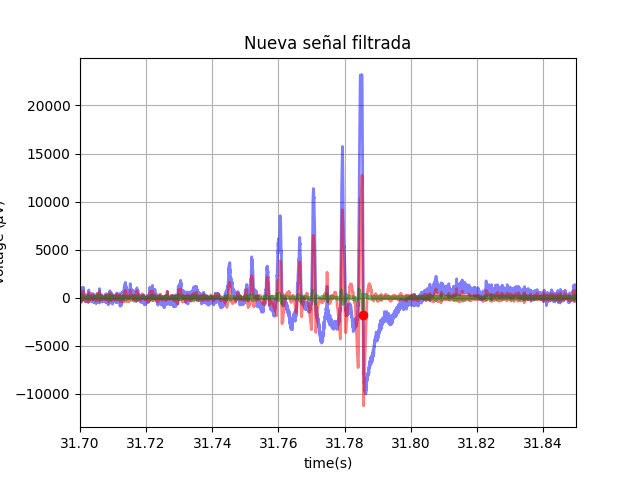

In [ ]:
derivada = np.gradient(filtered_data)
indice_mayor_derivada = np.argmax(np.abs(derivada))
valor_mayor_derivada = derivada[indice_mayor_derivada]
print(indice_mayor_derivada)


time = np.arange(len(derivada)) / fs

fig, ax = plt.subplots()

ax.plot(xx['timeEMG'],xx['waveData'],color='b',linewidth=2.0,alpha=0.5)
ax.plot(xx['timeEMG'],filtered_data, color='r',linewidth=2.0,alpha=0.5)
ax.plot(xx['timeEMG'],derivada,color='g',linewidth=2.0,alpha=0.5)
ax.plot(time[indice_mayor_derivada], valor_mayor_derivada, 'ro')

ax.set_title('Nueva señal filtrada')
ax.set_xlabel(r'time(s)')
ax.set_ylabel(r'voltage ($\mu$V)')
ax.grid(True)
#ax.set_xlim(0,max(time)) # Usar este límite de graficación para ver en qué punto se encuentra el pico
ax.set_xlim(31.7,31.85); # Ajustar los límites para enfocarse en el pico particular

plt.show()

Construimos además un función pequeña y simple que permite conocer el número de puntos en un intervalo y su duración en segundos, milisegundos y microsegundos. Todo esto al darle un tiempo de inicio, un punto de fin y la frecuencia de muestreo.

In [15]:
def contar_puntos(t_inicio, t_fin, fs):
  int = t_fin - t_inicio
  puntos = round(int * fs)
  duracion_seg = int
  duracion_ms = int * 1000
  duracion_microseg = duracion_ms * 1000

  print(f'El intervalo seleccionado tiene una duración de {duracion_seg} segundos, {duracion_ms} milisegundos, o  {duracion_microseg} microsegundos, además contiene {puntos} puntos.') 

In [16]:
contar_puntos(0.002,0.005,44100)

#Volts originales son Microvolts

El intervalo seleccionado tiene una duración de 0.003 segundos, 3.0 milisegundos, o  3000.0 microsegundos, además contiene 132 puntos.


### Filtrado y selección general de picos
A continuación se realiza el procedimiento original para encontrar picos visualmente al definir un límite inferior de inicio de picos. A esto le agregamos una función de zoom al final para poder enfocarse en picos particulares.

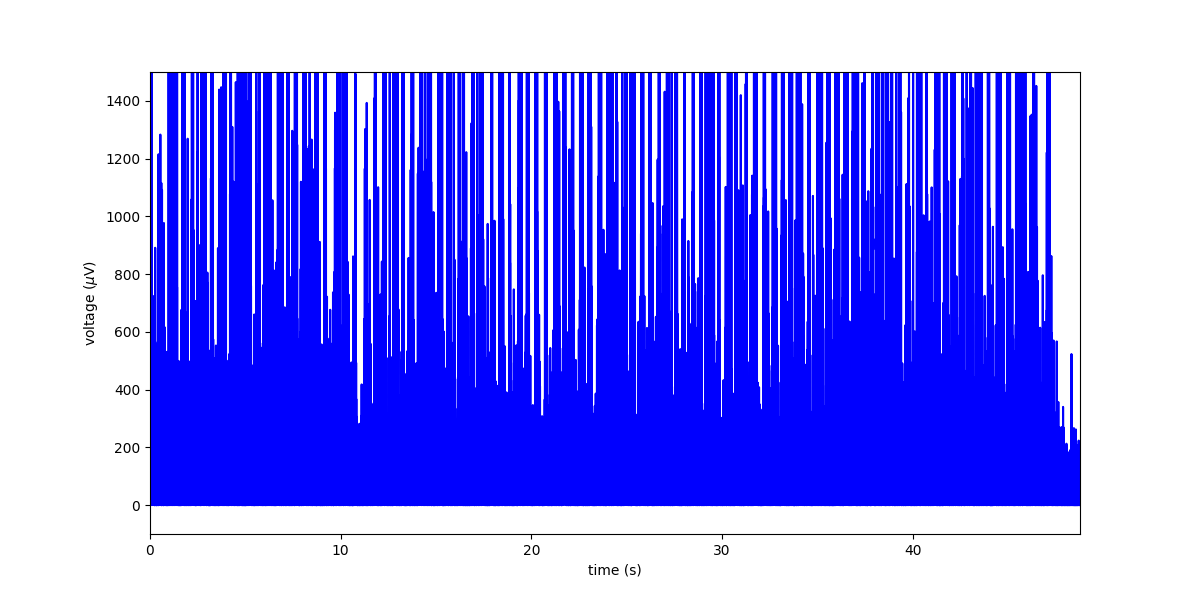

In [ ]:
# Filtro band-pass Butterworth configurado en el rango 10-400Hz
b, a = butter(2, ([10, 400]/(xx['freq']/2)), btype = 'bandpass')
dataf = filtfilt(b, a, xx['waveData'])
# rectifica la señal de EMG
absSignal = np.absolute(dataf)
timeAbs=np.linspace(0, len(absSignal)/xx['sampleRate'], num=len(absSignal))

# Muestra una nueva gráfica con la parte positiva de la señal
plt.figure(figsize=(12,6))
plt.xlabel(r'time (s)')
plt.ylabel(r'voltage ($\mu$V)')
plt.plot(xx['timeEMG'],absSignal,'b')
plt.xlim(0,max(xx['timeEMG']))
plt.ylim(-100,1500)
plt.show()

In [18]:
# low-pass Butterworth filter for envelope detection
lowp = 8
sfreq = xx['sampleRate']
low_pass = lowp/sfreq
b, a = sc.signal.butter(4, low_pass, btype='lowpass')
datafrle = filtfilt(b, a, absSignal)

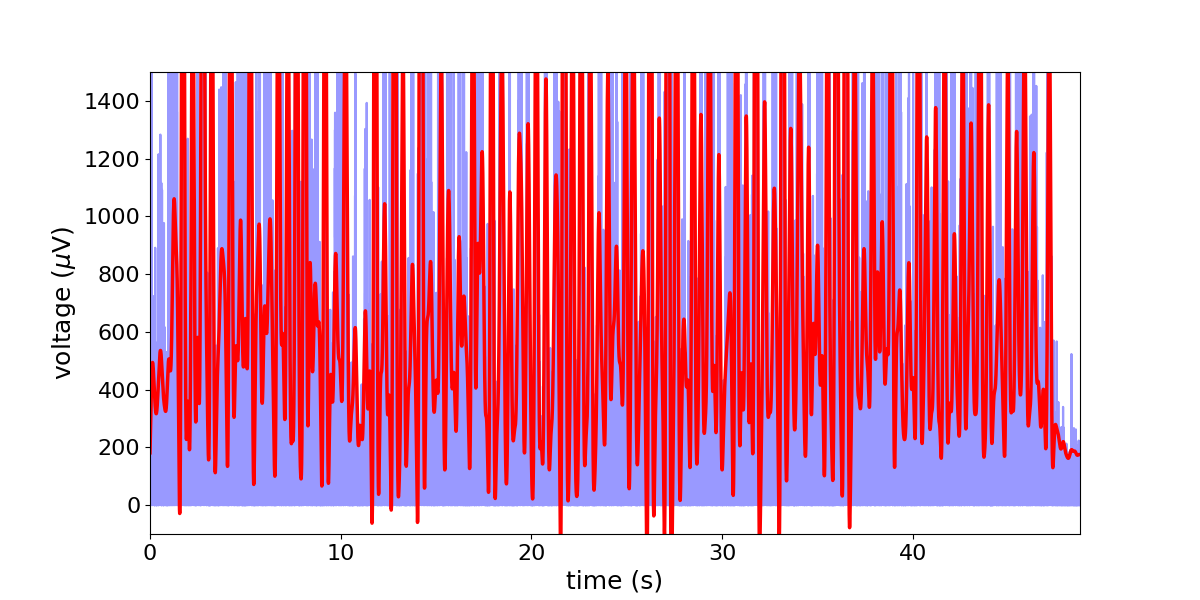

In [ ]:
# Hacemos una gráfica de la señal de EMG rectificada con un filtro de sobre
plt.figure(figsize=(12,6))
plt.xlabel('time (s)')
plt.ylabel('voltage ($\mu$V)')
plt.plot(timeAbs,absSignal, 'b', alpha=0.4)
plt.plot(timeAbs,datafrle*3, 'r', linewidth=2.5)
plt.xlim(0,max(xx['timeEMG']))
plt.ylim(-100,1500);

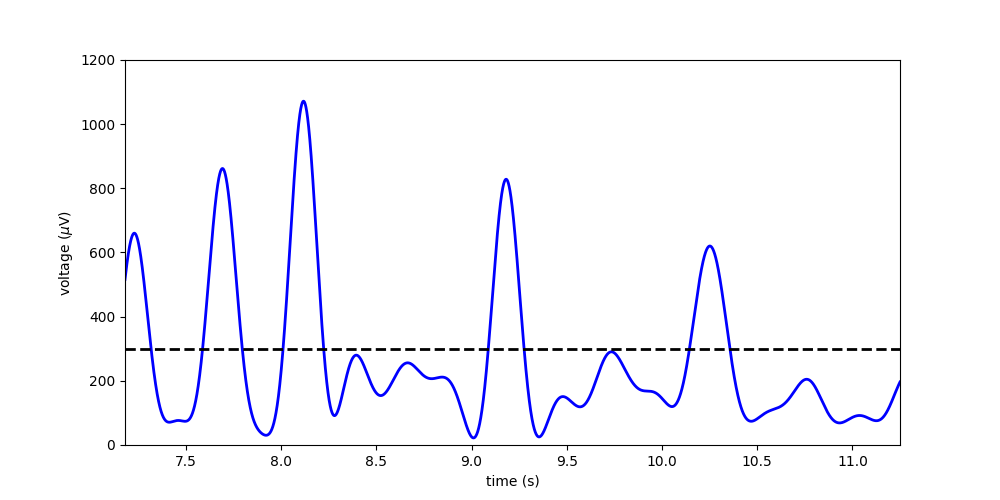

In [ ]:
# Graficamos la envoltura de la onda para determinar el límite inferior de los picos
#Colocamos la línea horizontal donde creemos que estará el límite y ajustamos hasta obtener un resultado satisfactorio
plt.figure(figsize=(10,5))
plt.xlabel('time (s)')
plt.ylabel('voltage ($\mu$V)')
plt.plot(timeAbs,datafrle, 'b', linewidth=2.0)
plt.axhline(y=300, color='k',linewidth=2.0, linestyle='--') # Línea horizontal que define el límite de los picos, ajustar a medida.
plt.xlim(7.18,11.25)
plt.ylim(0,1200);

Conforme al tutorial original, se hace un diccionario de tiempos de inicio y paro para los picos, que permitirá colocar marcas en los tiempos adecuados de la gráfica. Además, se agrega una función de zoom que permite enfocarse en picos, preservando las barras verticales que indican el inicio y fin de cada uno, respecto al criterio de suelo implementado.

In [20]:
threshold = 300 
cstarts = []
for i in range(1, len(datafrle)):
    if datafrle[i-1] < threshold and datafrle[i] >= threshold:
        cstarts.append(i)
        
print(cstarts) 

threshold = 300 
cstops = []
for i in range(1, len(datafrle)):
    if datafrle[i-1] >= threshold and datafrle[i] < threshold:
        cstops.append(i)
        
print(cstops)

starts=[]
for n in range(0, len(cstarts)):
    starttime = cstarts[n]/xx['sampleRate']
    starts.append(starttime)
    
print(starts)

stops=[]
for n in range(0, len(cstops)):
    stoptime = cstops[n]/xx['sampleRate']
    stops.append(stoptime)
    
print(stops)


[53021, 71865, 94901, 116636, 139097, 182425, 207741, 227446, 250172, 274941, 292645, 314930, 334606, 353242, 400777, 447365, 516517, 540387, 560919, 581336, 621479, 669664, 687744, 713834, 742819, 758143, 764018, 786141, 808742, 830083, 850439, 870815, 889308, 912403, 935301, 952457, 972994, 992699, 1014203, 1036304, 1055454, 1095958, 1113037, 1152340, 1174316, 1192352, 1212980, 1252089, 1270686, 1288980, 1312932, 1351970, 1375840, 1396430, 1417744, 1440830, 1458124, 1477955, 1496918, 1520410, 1562928, 1582367, 1603937, 1625192, 1667167, 1691483, 1709338, 1772373, 1792623, 1813407, 1833665, 1858827, 1875324, 1894756, 1914323, 1935897, 1980181, 2000862, 2017749, 2040748, 2075558]
[60170, 80992, 102652, 128751, 147030, 191187, 211112, 236290, 254051, 279946, 301467, 322682, 343801, 362653, 409063, 456730, 525539, 544532, 570536, 588270, 632102, 677101, 693252, 715742, 750893, 759116, 771170, 794637, 818282, 834116, 860432, 877551, 897830, 918686, 942958, 962907, 980995, 1001316, 1021794

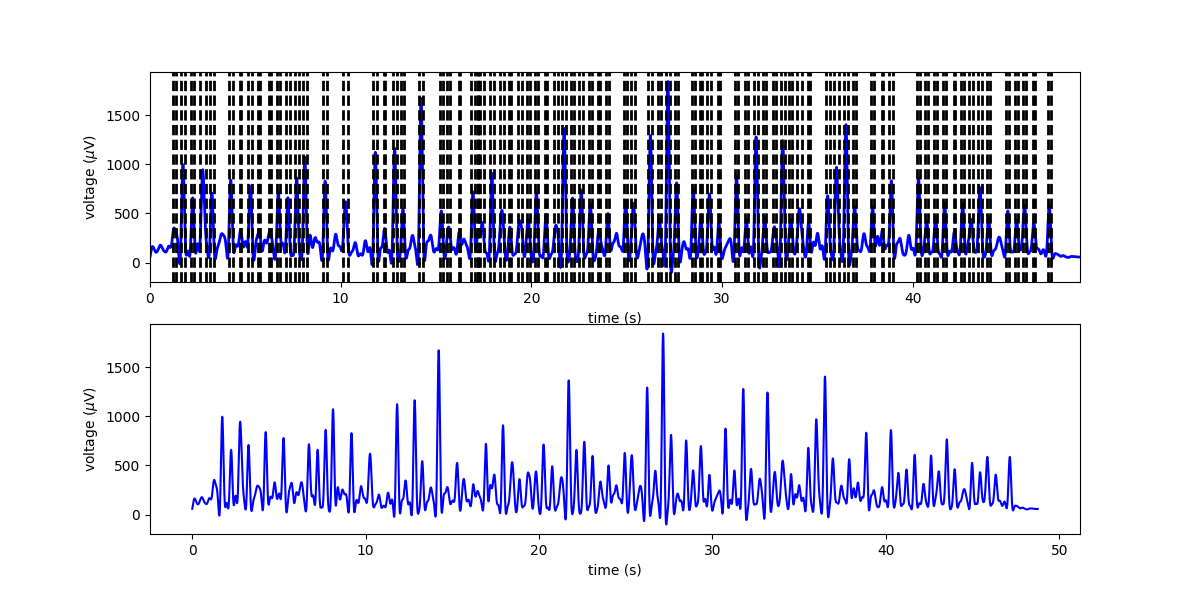

In [ ]:

fig, (ax1,ax2) = plt.subplots(2,figsize=(12,6))

ax1.set_xlabel('time (s)')
ax1.set_ylabel('voltage ($\mu$V)')
ax1.plot(timeAbs, datafrle, 'b', linewidth=2.0)      
for n in range(0, len(starts)):
    ax1.axvline(x=starts[n], color='k',linewidth=2.0, linestyle='--')
for n in range(0, len(stops)):
    ax1.axvline(x=stops[n], color='k',linewidth=2.0, linestyle='--')

line2, = ax2.plot(timeAbs, datafrle, 'b')
ax2.set_xlabel(r'time (s)')
ax2.set_ylabel(r'voltage ($\mu$V)')

def onselect(xmin, xmax):
    indmin, indmax = np.searchsorted(timeAbs, (xmin, xmax))
    indmax = min(len(timeAbs) - 1, indmax)

    thisx = timeAbs[indmin:indmax]
    thisy = datafrle[indmin:indmax]
    line2.set_data(thisx, thisy)
    ax2.set_xlim(thisx[0], thisx[-1])
    ax2.set_ylim(thisy.min(), thisy.max())

    # Mostrar las líneas verticales también en la gráfica de enfoque
    for n in range(0, len(starts)):
        if xmin <= starts[n] <= xmax:
            ax2.axvline(x=starts[n], color='k', linewidth=2.0, linestyle='--')
    for n in range(0, len(stops)):
        if xmin <= stops[n] <= xmax:
            ax2.axvline(x=stops[n], color='k', linewidth=2.0, linestyle='--')


    fig.canvas.draw()
    

span = SpanSelector(ax1, onselect, 'horizontal', useblit=True,
                    props=dict(alpha=0.5, facecolor='red'))
    
ax1.set_xlim(0, max(xx['timeEMG']));